## Calculate QC metrics for integrated fiber dataset, and plot PCA/UMAP to check sample batch effects

In [57]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.sparse import issparse

In [58]:
cd ../../data/IBM

/exports/archive/hg-groep-spitali/Students/Caro/data/IBM


/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [66]:
adata_fibers = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers.h5ad')
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean'
    obsm: 'spatial'
    layers: 'integrated_raw'

In [67]:
# Calculate QC metrics for integrated gene counts
sc.pp.calculate_qc_metrics(adata_fibers, inplace=True)

In [68]:
# Added .var columns (per gene): 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
adata_fibers.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,41,0.004572,0.004562,99.542768,41,3.737670
AAMP,8787,8.412066,2.241993,2.007360,75431,11.230987
AAR2,2216,0.330322,0.285421,75.287164,2962,7.993958
AARSD1,7225,2.574328,1.273777,19.426787,23084,10.046938
ABAT,949,0.138173,0.129425,89.416750,1239,7.122867
...,...,...,...,...,...,...
XCR1,1164,0.171295,0.158110,87.019070,1536,7.337588
XIRP2,8957,116.880339,4.769670,0.111520,1048066,13.862458
YBX3,8965,172.651835,5.157052,0.022304,1548169,14.252584
ZKSCAN3,5329,1.222929,0.798825,40.570982,10966,9.302646


In [69]:
# Added .obs columns (per fiber): 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
adata_fibers.obs

,cell_ID,fov_labels,sample_id,condition,muscle_type,sample_id_new,cell_type_annotation,cell_type_annotation_clean,sample_condition,unique_cell_ID_5000,...,B_cells_in_neighborhood_200_5000,B_cells_in_neighborhood_200_mean,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
0,130,segmentation_mask_boundaries_1_filt_2_label,sample1,ibm,TA,sample1,7-Myofibertype1,Myofibers type 1,Sample 1 - IBM,130_segmentation_mask_boundaries_1_filt_2_label,...,0,0.0,2644,7.880426,83002,11.326632,64.011711,73.864485,81.140213,89.717115
1,132,segmentation_mask_boundaries_1_filt_2_label,sample1,ibm,TA,sample1,7-Myofibertype1,Myofibers type 1,Sample 1 - IBM,132_segmentation_mask_boundaries_1_filt_2_label,...,0,0.0,2710,7.905073,130685,11.780553,64.659295,75.160883,82.356812,90.734973
4,150,segmentation_mask_boundaries_1_filt_2_label,sample1,ibm,TA,sample1,7-Myofibertype1,Myofibers type 1,Sample 1 - IBM,150_segmentation_mask_boundaries_1_filt_2_label,...,0,0.0,2996,8.005367,85770,11.359436,58.561269,68.577591,76.463799,86.207299
5,151,segmentation_mask_boundaries_1_filt_2_label,sample1,ibm,TA,sample1,7-Myofibertype1,Myofibers type 1,Sample 1 - IBM,151_segmentation_mask_boundaries_1_filt_2_label,...,0,0.0,2983,8.001020,185675,12.131758,67.536825,77.631884,84.074323,91.447422
6,152,segmentation_mask_boundaries_1_filt_2_label,sample1,ibm,TA,sample1,4-Myonucleitype2-2,Myofibers type 2,Sample 1 - IBM,152_segmentation_mask_boundaries_1_filt_2_label,...,0,0.0,2895,7.971086,129904,11.774559,61.926500,73.106294,81.005204,89.951041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10804,129,shape_seg7_man_1211_label,sample7,ibm,TA,sample1,7-Myofibertype1,Myofibers type 1,Sample 1 - IBM,129_shape_seg7_man_1211_label,...,0,0.0,2152,7.674617,57854,10.965695,64.291147,74.707021,82.315830,91.122481
10807,132,shape_seg7_man_1211_label,sample7,ibm,TA,sample1,4-Myonucleitype2-2,Myofibers type 2,Sample 1 - IBM,132_shape_seg7_man_1211_label,...,0,0.0,1829,7.512071,12095,9.400630,40.934270,52.550641,64.299297,80.090947
10808,133,shape_seg7_man_1211_label,sample7,ibm,TA,sample1,4-Myonucleitype2-2,Myofibers type 2,Sample 1 - IBM,133_shape_seg7_man_1211_label,...,0,0.0,2379,7.774856,20922,9.948604,48.092917,58.187554,67.369276,80.202657
10810,135,shape_seg7_man_1211_label,sample7,ibm,TA,sample1,4-Myonucleitype2-2,Myofibers type 2,Sample 1 - IBM,135_shape_seg7_man_1211_label,...,0,0.0,2897,7.971776,70410,11.162105,53.273683,65.120011,73.739526,84.875728


<Axes: xlabel='log1p_total_counts', ylabel='Count'>

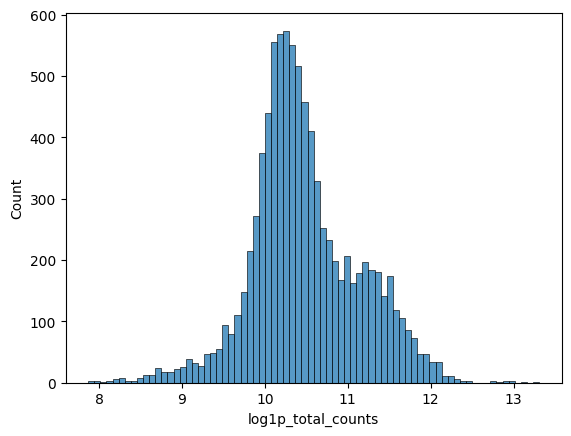

In [70]:
sns.histplot(adata_fibers.obs["log1p_total_counts"])

In [10]:
min(adata_fibers.obs["total_counts"])

2614

All fibers have >2614 counts (no filtering needed, low count fibers were previously filtered out)

<Axes: xlabel='n_cells_by_counts', ylabel='Count'>

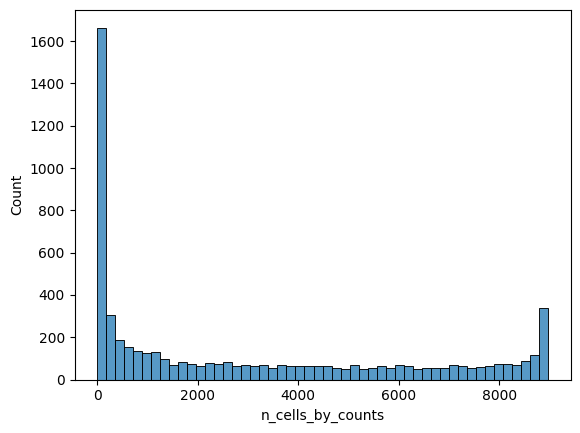

In [15]:
sns.histplot(adata_fibers.var["n_cells_by_counts"], bins=50)

<Axes: xlabel='pct_dropout_by_counts', ylabel='Count'>

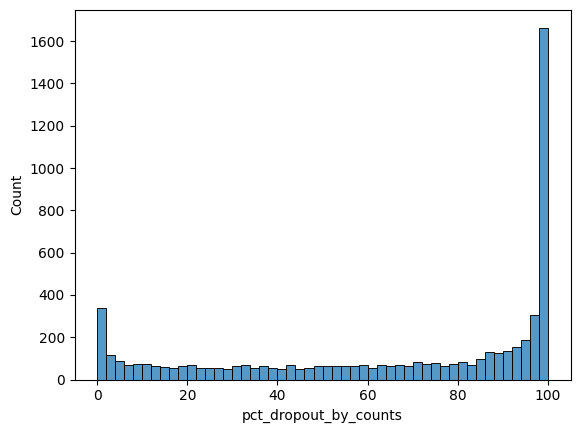

In [11]:
sns.histplot(adata_fibers.var["pct_dropout_by_counts"], bins=50)

In [71]:
adata_fibers.var[adata_fibers.var["pct_dropout_by_counts"] > 99]

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,41,0.004572,0.004562,99.542768,41,3.737670
ACOD1,37,0.004461,0.004451,99.587376,40,3.713572
ACPP,74,0.008810,0.008771,99.174752,79,4.382027
ACTBL2,37,0.004126,0.004118,99.587376,37,3.637586
ADCYAP1,36,0.004238,0.004229,99.598528,38,3.663562
...,...,...,...,...,...,...
VSX2,61,0.006914,0.006890,99.319728,62,4.143135
WDR72,58,0.006580,0.006558,99.353184,59,4.094345
WNT2,81,0.009479,0.009435,99.096688,85,4.454347
WT1,33,0.003792,0.003785,99.631984,34,3.555348


In [18]:
adata_fibers.var[adata_fibers.var["pct_dropout_by_counts"] > 99.5]

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,41,0.004572,0.004562,99.542768,41,3.737670
ACOD1,37,0.004461,0.004451,99.587376,40,3.713572
ACTBL2,37,0.004126,0.004118,99.587376,37,3.637586
ADCYAP1,36,0.004238,0.004229,99.598528,38,3.663562
ADRB3,24,0.002676,0.002673,99.732352,24,3.218876
...,...,...,...,...,...,...
TNFSF18,23,0.002565,0.002562,99.743504,23,3.178054
UGT2B17,34,0.003903,0.003896,99.620832,35,3.583519
UGT2B7,36,0.004126,0.004118,99.598528,37,3.637586
UTS2,33,0.003792,0.003785,99.631984,34,3.555348


872 genes have 0 counts in >99.5% of the fibers (at least 1 count in <45 fibers)\
1274 genes have 0 counts in >99% of the fibers (at least 1 count in <90 fibers)

## Perform PCA and plot UMAP
Are samples separated in the UMAP? > Then batch correction with trVAE is probably needed before pseudotime analysis with Palantir

### Without gene count filtering

In [72]:
# Normalizing to 10000 counts
sc.pp.normalize_total(adata_fibers, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_fibers)

adata_fibers.layers["counts_norm_log"] = adata_fibers.X.copy()

In [8]:
adata_fibers.obs['cell_type_annotation_fiber_subtypes'].value_counts()

cell_type_annotation_fiber_subtypes
Myofibers type 1                 6700
Myofibers type 2x                1146
Myofibers type 2a                 559
Damaged myofibers type 2          295
Regenerative myofibers type 2     264
Low quality                         3
Myonuclei type 1                    0
Myonuclei type 2                    0
CD8 T-cells                         0
CD4 T-cells                         0
B-cells                             0
FAPs/Collagen                       0
Satellite cells                     0
Endothelial cells                   0
Pericytes                           0
Name: count, dtype: int64

In [74]:
adata_fibers.X

array([[0.        , 0.79063237, 0.11375628, ..., 3.8061032 , 0.21588369,
        0.        ],
       [0.        , 0.69052297, 0.0737335 , ..., 3.4387767 , 0.0737335 ,
        0.14240173],
       [0.        , 1.0527269 , 0.        , ..., 3.6272578 , 0.        ,
        0.        ],
       ...,
       [0.        , 1.668026  , 0.        , ..., 2.698741  , 0.        ,
        0.88949376],
       [0.        , 1.545999  , 0.25001958, ..., 3.0789557 , 0.4498654 ,
        0.4498654 ],
       [0.        , 1.0229806 , 0.        , ..., 3.957119  , 0.30475637,
        0.        ]], shape=(8967, 5850), dtype=float32)

In [73]:
sc.pp.highly_variable_genes(adata_fibers, n_top_genes=1500, flavor="cell_ranger")

In [75]:
adata_fibers.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
A2ML1,41,0.004572,0.004562,99.542768,41,3.737670,False,0.000754,0.223797,-0.798999
AAMP,8787,8.412066,2.241993,2.007360,75431,11.230987,False,1.021372,0.139590,-0.371162
AAR2,2216,0.330322,0.285421,75.287164,2962,7.993958,False,0.064757,0.299733,-0.228894
AARSD1,7225,2.574328,1.273777,19.426787,23084,10.046938,False,0.424410,0.216541,-0.430093
ABAT,949,0.138173,0.129425,89.416750,1239,7.122867,False,0.023030,0.277340,-0.871992
...,...,...,...,...,...,...,...,...,...,...
XCR1,1164,0.171295,0.158110,87.019070,1536,7.337588,True,0.029937,0.348384,1.022252
XIRP2,8957,116.880339,4.769670,0.111520,1048066,13.862458,True,2.790560,0.238206,2.754373
YBX3,8965,172.651835,5.157052,0.022304,1548169,14.252584,False,3.663312,0.027287,-1.331651
ZKSCAN3,5329,1.222929,0.798825,40.570982,10966,9.302646,False,0.230850,0.285886,0.851478


In [76]:
adata_fibers.var["highly_variable"][adata_fibers.var["pct_dropout_by_counts"] > 99].value_counts()

highly_variable
False    983
True     291
Name: count, dtype: int64

<Axes: xlabel='pct_dropout_by_counts', ylabel='Count'>

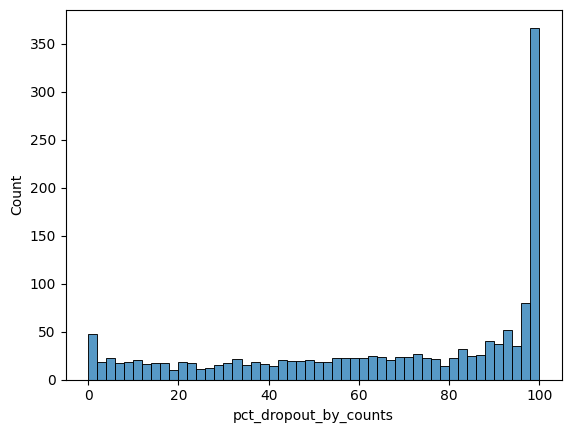

In [15]:
sns.histplot(adata_fibers.var["pct_dropout_by_counts"][adata_fibers.var["highly_variable"] == True], bins=50)

In [16]:
sum((adata_fibers.var["highly_variable"]) & (adata_fibers.var["pct_dropout_by_counts"] > 95))

463

Without filtering out lowly expressed genes, these will dominate in the 1500 highly variable genes.\
463/1500 highly variable genes have counts in <5% of the fibers.

In [17]:
# Calculate PCA (By default uses highly variable genes)
sc.pp.pca(adata_fibers)
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts

In [18]:
# Calculate 15 nearest neighbors in X_pca space
sc.pp.neighbors(adata_fibers)
# Calculate UMAP using nn's
sc.tl.umap(adata_fibers)

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts

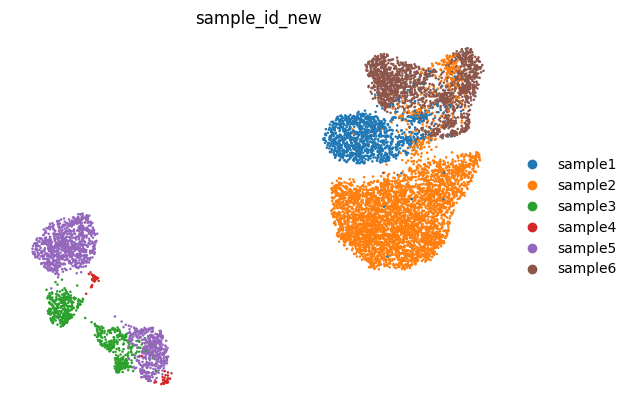

In [20]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)

#### Calculate PCA/UMAP using sparrow/sandra's parameters

In [77]:
# calculate PCA + UMAP (Sandra's params)
sc.pp.pca(adata_fibers, n_comps=50) #n_comps=50 is default
sc.pp.neighbors(adata_fibers, n_neighbors=15, n_pcs=10) #n_neighbors=15 is default
sc.tl.umap(adata_fibers)

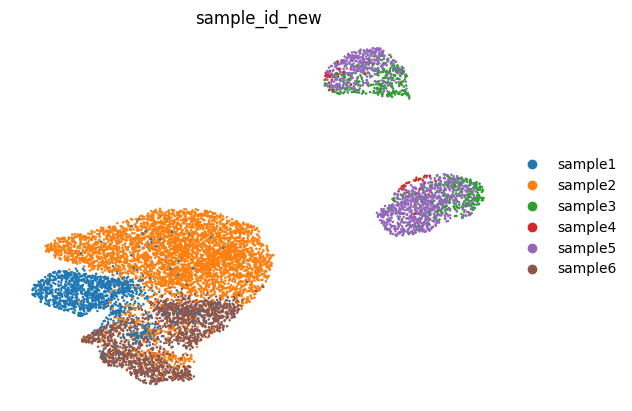

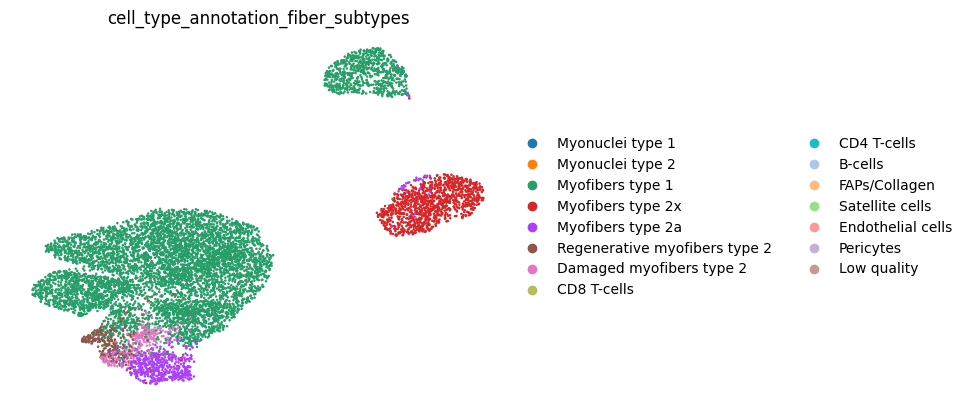

In [78]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="cell_type_annotation_fiber_subtypes",
    sort_order=False,
    frameon=False,
)

In [79]:
# Save preprocessed (not filtered) anndata
adata_fibers.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_unfiltered.h5ad")

### With gene count filtering
Filter genes to be expressed in >1% of fibers (0.01*8967 = 90 fibers)

In [80]:
# Reload clean data  
adata_fibers = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers.h5ad')
sc.pp.calculate_qc_metrics(adata_fibers, inplace=True)

In [81]:
# Filter out genes expressed in <90 (1%) fibers
sc.pp.filter_genes(adata_fibers, min_cells=90)

In [82]:
# This filtering leaves 4567 genes
adata_fibers.var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
AAMP,8787,8.412066,2.241993,2.007360,75431,11.230987,8787
AAR2,2216,0.330322,0.285421,75.287164,2962,7.993958,2216
AARSD1,7225,2.574328,1.273777,19.426787,23084,10.046938,7225
ABAT,949,0.138173,0.129425,89.416750,1239,7.122867,949
ABCA1,7671,4.863499,1.768747,14.452994,43611,10.683088,7671
...,...,...,...,...,...,...,...
XCR1,1164,0.171295,0.158110,87.019070,1536,7.337588,1164
XIRP2,8957,116.880339,4.769670,0.111520,1048066,13.862458,8957
YBX3,8965,172.651835,5.157052,0.022304,1548169,14.252584,8965
ZKSCAN3,5329,1.222929,0.798825,40.570982,10966,9.302646,5329


In [83]:
# Normalizing to 10000 counts
sc.pp.normalize_total(adata_fibers, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_fibers)

adata_fibers.layers["counts_norm_log"] = adata_fibers.X.copy()

In [84]:
sc.pp.highly_variable_genes(adata_fibers, n_top_genes=1500, flavor="cell_ranger")

<Axes: xlabel='pct_dropout_by_counts', ylabel='Count'>

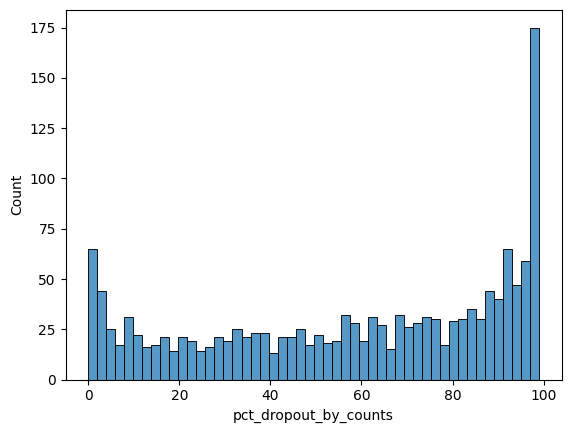

In [30]:
sns.histplot(adata_fibers.var["pct_dropout_by_counts"][adata_fibers.var["highly_variable"] == True], bins=50)

In [85]:
# Calculate PCA (By default uses highly variable genes)
sc.pp.pca(adata_fibers, n_comps=50)
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 4576
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_coun

In [86]:
# Calculate 15 nearest neighbors in X_pca space
sc.pp.neighbors(adata_fibers, n_pcs=10)
# Calculate UMAP using nn's
sc.tl.umap(adata_fibers)

In [33]:
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 4576
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts

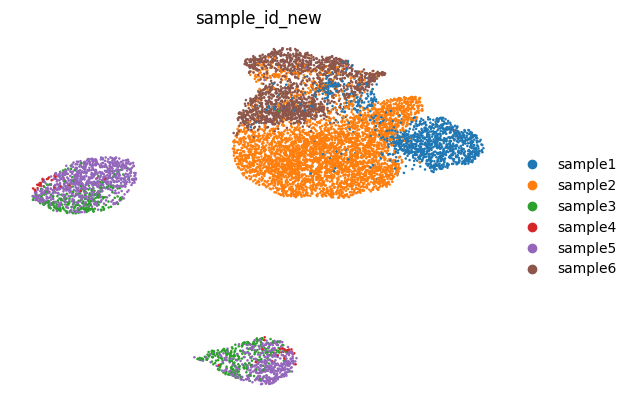

In [87]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)

In [88]:
# Save preprocessed and filtered anndata
adata_fibers.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_filtered.h5ad")

## Load trVAE batch corrected data and plot UMAP

### Without gene count filtering

In [27]:
adata_fibers_trvae = sc.read_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_unfiltered.h5ad")
adata_fibers_trvae

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'sample_id_new_colors', 'umap'
    obsm: 'X_pca', 'X_trVAE', 'X_umap'
    va

In [28]:
adata_fibers_trvae.obs['cell_type_annotation_fiber_subtypes'].value_counts()

cell_type_annotation_fiber_subtypes
Myofibers type 1                 6700
Myofibers type 2x                1146
Myofibers type 2a                 559
Damaged myofibers type 2          295
Regenerative myofibers type 2     264
Low quality                         3
Myonuclei type 2                    0
Myonuclei type 1                    0
CD8 T-cells                         0
B-cells                             0
CD4 T-cells                         0
FAPs/Collagen                       0
Satellite cells                     0
Endothelial cells                   0
Pericytes                           0
Name: count, dtype: int64

In [33]:
adata_fibers_trvae.obs['cell_type_annotation_fiber_subtypes'] = adata_fibers_trvae.obs['cell_type_annotation_fiber_subtypes'].cat.remove_unused_categories()

In [34]:
# Calculate 15 nearest neighbors in X_trVAE space
sc.pp.neighbors(adata_fibers_trvae, use_rep="X_trVAE", n_neighbors=15)
# Calculate UMAP using nn's
sc.tl.umap(adata_fibers_trvae)

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


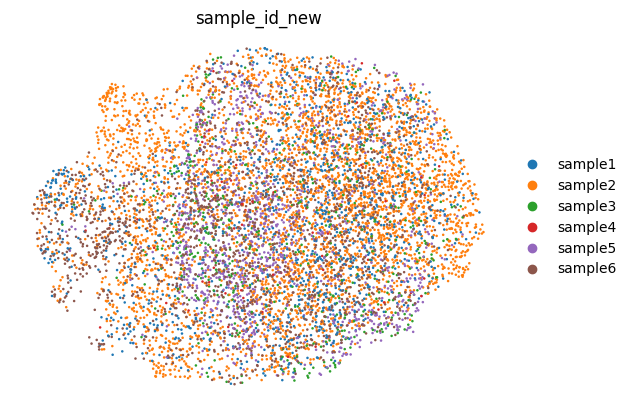

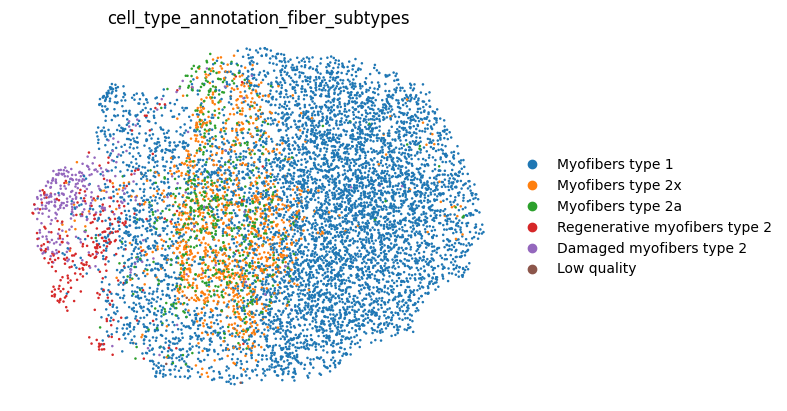

In [35]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers_trvae,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)
sc.pl.embedding(
    adata_fibers_trvae,
    basis="X_umap",
    color="cell_type_annotation_fiber_subtypes",
    sort_order=False,
    frameon=False,
)

### With gene count filtering

In [32]:
adata_fibers_trvae = sc.read_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_trvae_filtered.h5ad")
adata_fibers_trvae

AnnData object with n_obs × n_vars = 8967 × 4576
    obs: 'cell_ID', 'fov_labels', 'shapeSize', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'n

In [33]:
adata_fibers_trvae.obs['cell_type_annotation_fiber_subtypes'].value_counts()

cell_type_annotation_fiber_subtypes
Myofibers type 1                 6700
Myofibers type 2x                1146
Myofibers type 2a                 559
Damaged myofibers type 2          295
Regenerative myofibers type 2     264
Low quality                         3
Name: count, dtype: int64

In [34]:
# Calculate 15 nearest neighbors in X_trVAE space
sc.pp.neighbors(adata_fibers_trvae, use_rep="X_trVAE", random_state=1, n_neighbors=15)
# Calculate UMAP using nn's
sc.tl.umap(adata_fibers_trvae)

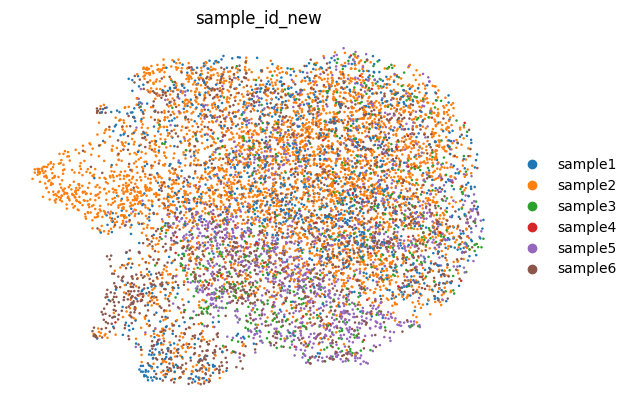

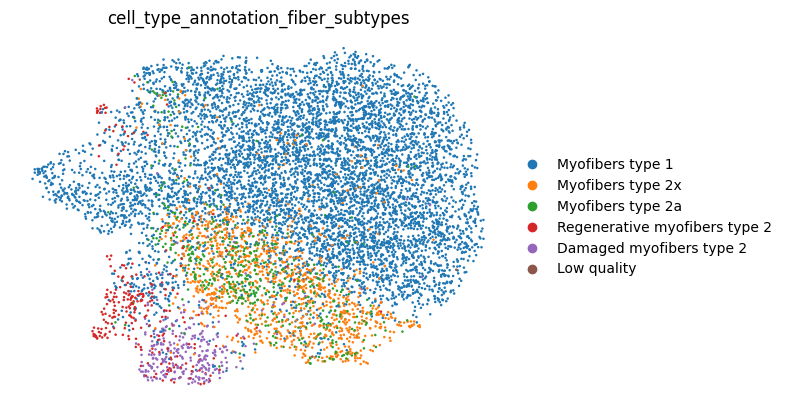

In [33]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers_trvae,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)
sc.pl.embedding(
    adata_fibers_trvae,
    basis="X_umap",
    color="cell_type_annotation_fiber_subtypes",
    sort_order=False,
    frameon=False,
)

## Size normalize integrated gene counts
- Unique 5000-genes are normalized to the 5000-genes slide fiber size (shape_size_5000)
- Unique 480-genes are normalized to the 480-genes slide fiber size (shape_size_480)
- Overlapping genes (mean counts) are normalized to the mean fiber size from both slides (shape_size_mean)
- \> counts layer 'size_normalized'

- all normalized genes are logarithmized (log1p) > counts layer 'size_normalized_log'
- all genes are scaled (mean=0, sd=1) > counts layer 'size_normalized_log_scaled'

In [89]:
# load (unfiltered) integrated adata
adata_fibers = sc.read_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_preprocessed_unfiltered.h5ad")

In [90]:
np.mean(adata_fibers.obs['shape_size_mean']) #mean shape size

np.float64(139735.51793665747)

Mean matched shape size = 139735, I will normalize counts to size=140000

In [91]:
# Get lists of unique and overlapping gene names
adata_480 = sc.read_h5ad('cellcharter_clusters_anndata/480_dataset/adata_480_fibnuc_spatial_niches.h5ad')
adata_5000 = sc.read_h5ad('cellcharter_clusters_anndata/5000_dataset/adata_5000_fibnuc_spatial_niches.h5ad')

genes_480 = adata_480.var_names
genes_5000 = adata_5000.var_names

unique_5000 = set(genes_5000) - set(genes_480)
unique_480 = set(genes_480) - set(genes_5000)
overlapping_genes = set(genes_5000) & set(genes_480)

print(len(unique_5000))
print(len(unique_480))
print(len(overlapping_genes))

5370
279
201


In [92]:
X = adata_fibers.layers['integrated_raw'].copy().astype('float32')
X

array([[  0.,  10.,   1., ..., 365.,   2.,   0.],
       [  0.,  13.,   1., ..., 394.,   1.,   2.],
       [  0.,  16.,   0., ..., 314.,   0.,   0.],
       ...,
       [  0.,   9.,   0., ...,  29.,   0.,   3.],
       [  0.,  26.,   2., ..., 146.,   4.,   4.],
       [  0.,  15.,   0., ..., 432.,   3.,   0.]],
      shape=(8967, 5850), dtype=float32)

In [93]:
adata_fibers

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_coun

In [94]:
# Get gene index mappings
gene_names = list(adata_fibers.var_names)
idx_5000 = [gene_names.index(g) for g in unique_5000]
idx_480  = [gene_names.index(g) for g in unique_480]
idx_mean = [gene_names.index(g) for g in overlapping_genes]

# Get fiber size vectors
sizes_5000 = adata_fibers.obs['shape_size_5000'].values
sizes_480  = adata_fibers.obs['shape_size_480'].values
sizes_mean = adata_fibers.obs['shape_size_mean'].values

# Normalize each gene group by its corresponding size vector (normalized to size=140000, =mean fiber size)
# Size normalization code modified from Sparrow
X[:, idx_5000] = (X[:, idx_5000].T * 140000 / sizes_5000).T
X[:, idx_480]  = (X[:, idx_480].T  * 140000 / sizes_480).T
X[:, idx_mean] = (X[:, idx_mean].T * 140000 / sizes_mean).T

# Store back
adata_fibers.X = X
adata_fibers.layers["size_normalized"] = X.copy()

In [95]:
adata_fibers.layers["integrated_raw"]

array([[  0,  10,   1, ..., 365,   2,   0],
       [  0,  13,   1, ..., 394,   1,   2],
       [  0,  16,   0, ..., 314,   0,   0],
       ...,
       [  0,   9,   0, ...,  29,   0,   3],
       [  0,  26,   2, ..., 146,   4,   4],
       [  0,  15,   0, ..., 432,   3,   0]],
      shape=(8967, 5850), dtype=uint32)

In [96]:
adata_fibers.layers["size_normalized"]

array([[  0.        ,   6.1322694 ,   0.61322695, ..., 213.35493   ,
          1.1690681 ,   0.        ],
       [  0.        ,   4.789482  ,   0.3684217 , ..., 137.4156    ,
          0.3487706 ,   0.6975412 ],
       [  0.        ,   8.551013  ,   0.        , ..., 174.9993    ,
          0.        ,   0.        ],
       ...,
       [  0.        ,  55.198074  ,   0.        , ..., 215.27669   ,
          0.        ,  22.270002  ],
       [  0.        ,  23.828821  ,   1.8329864 , ..., 165.91043   ,
          4.545491  ,   4.545491  ],
       [  0.        ,   8.728103  ,   0.        , ..., 241.10315   ,
          1.6743274 ,   0.        ]], shape=(8967, 5850), dtype=float32)

In [97]:
# Logarithmize size normalized counts
sc.pp.log1p(adata_fibers)
adata_fibers.layers["size_normalized_log"] = adata_fibers.X.copy()

In [98]:
adata_fibers.layers['size_normalized_log']

array([[0.        , 1.9646294 , 0.4782365 , ..., 5.3676333 , 0.7742976 ,
        0.        ],
       [0.        , 1.7560428 , 0.31365803, ..., 4.9302607 , 0.2991935 ,
        0.5291808 ],
       [0.        , 2.256647  , 0.        , ..., 5.17048   , 0.        ,
        0.        ],
       ...,
       [0.        , 4.0288825 , 0.        , ..., 5.3765583 , 0.        ,
        3.147165  ],
       [0.        , 3.2120051 , 1.0413314 , ..., 5.1174574 , 1.7129853 ,
        1.7129853 ],
       [0.        , 2.275019  , 0.        , ..., 5.4893637 , 0.9836979 ,
        0.        ]], shape=(8967, 5850), dtype=float32)

In [99]:
# calculate PCA + UMAP (Sandra's params)
sc.pp.pca(adata_fibers, n_comps=50) #n_comps=50 is default
sc.pp.neighbors(adata_fibers, n_neighbors=15, n_pcs=10) #n_neighbors=15 is default
sc.tl.umap(adata_fibers)

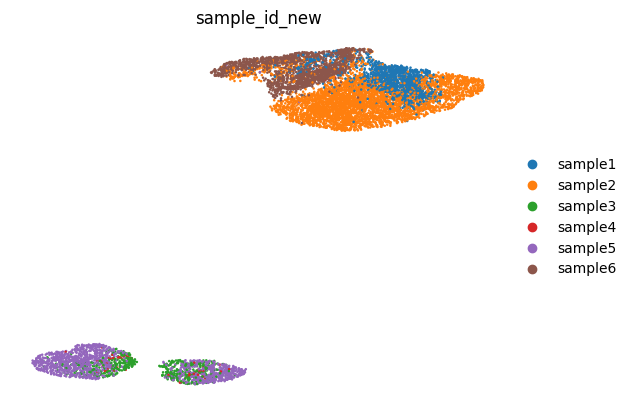

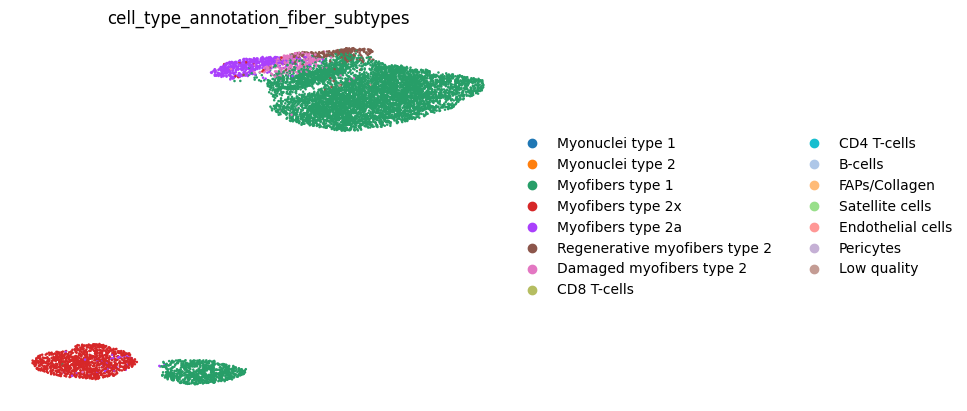

In [100]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="cell_type_annotation_fiber_subtypes",
    sort_order=False,
    frameon=False,
)

In [101]:
adata_fibers.X = adata_fibers.layers['size_normalized_log'].copy()

In [102]:
# Scale data
sc.pp.scale(adata_fibers, zero_center=True, max_value=10)

In [103]:
adata_fibers.layers["size_normalized_log_scaled"] = adata_fibers.X.copy()

In [104]:
# calculate PCA + UMAP (Sandra's params)
sc.pp.pca(adata_fibers, n_comps=50) #n_comps=50 is default
sc.pp.neighbors(adata_fibers, n_neighbors=15, n_pcs=10) #n_neighbors=15 is default
sc.tl.umap(adata_fibers)

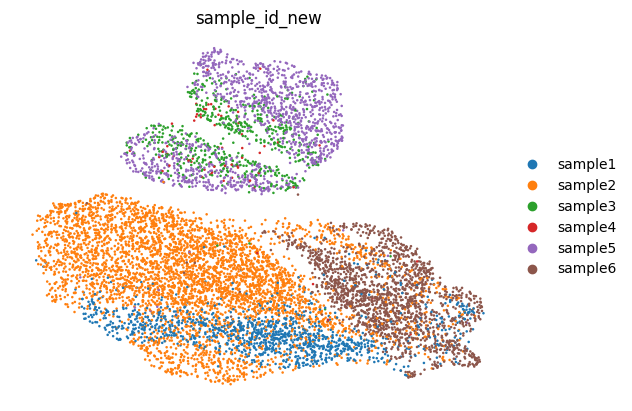

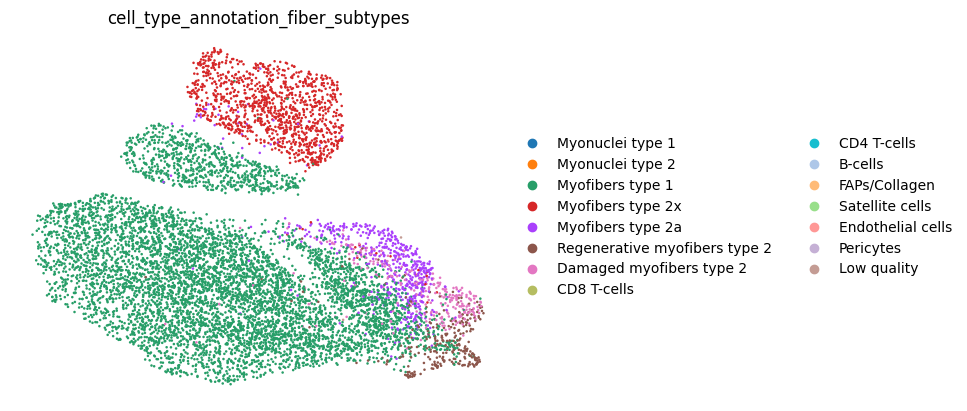

In [105]:
# Plot UMAP
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="sample_id_new",
    sort_order=False,
    frameon=False,
)
sc.pl.embedding(
    adata_fibers,
    basis="X_umap",
    color="cell_type_annotation_fiber_subtypes",
    sort_order=False,
    frameon=False,
)

In [106]:
adata_fibers.layers['size_normalized']

array([[  0.        ,   6.1322694 ,   0.61322695, ..., 213.35493   ,
          1.1690681 ,   0.        ],
       [  0.        ,   4.789482  ,   0.3684217 , ..., 137.4156    ,
          0.3487706 ,   0.6975412 ],
       [  0.        ,   8.551013  ,   0.        , ..., 174.9993    ,
          0.        ,   0.        ],
       ...,
       [  0.        ,  55.198074  ,   0.        , ..., 215.27669   ,
          0.        ,  22.270002  ],
       [  0.        ,  23.828821  ,   1.8329864 , ..., 165.91043   ,
          4.545491  ,   4.545491  ],
       [  0.        ,   8.728103  ,   0.        , ..., 241.10315   ,
          1.6743274 ,   0.        ]], shape=(8967, 5850), dtype=float32)

In [107]:
adata_fibers.layers['size_normalized_log']

array([[0.        , 1.9646294 , 0.4782365 , ..., 5.3676333 , 0.7742976 ,
        0.        ],
       [0.        , 1.7560428 , 0.31365803, ..., 4.9302607 , 0.2991935 ,
        0.5291808 ],
       [0.        , 2.256647  , 0.        , ..., 5.17048   , 0.        ,
        0.        ],
       ...,
       [0.        , 4.0288825 , 0.        , ..., 5.3765583 , 0.        ,
        3.147165  ],
       [0.        , 3.2120051 , 1.0413314 , ..., 5.1174574 , 1.7129853 ,
        1.7129853 ],
       [0.        , 2.275019  , 0.        , ..., 5.4893637 , 0.9836979 ,
        0.        ]], shape=(8967, 5850), dtype=float32)

In [108]:
adata_fibers.layers['size_normalized_log_scaled']

array([[-0.06051297, -0.22890764,  0.6705151 , ...,  0.73710763,
         0.1940908 , -0.6349793 ],
       [-0.06051297, -0.528907  ,  0.2692991 , ..., -0.51455355,
        -0.5283883 ,  0.3828529 ],
       [-0.06051297,  0.19108644, -0.49534908, ...,  0.17289895,
        -0.9833645 , -0.6349793 ],
       ...,
       [-0.06051297,  2.7400017 , -0.49534908, ...,  0.7626489 ,
        -0.9833645 ,  5.4183125 ],
       [-0.06051297,  1.5651289 ,  2.0432506 , ...,  0.02116093,
         1.6215302 ,  2.6597955 ],
       [-0.06051297,  0.21750969, -0.49534908, ...,  1.0854722 ,
         0.5125207 , -0.6349793 ]], shape=(8967, 5850), dtype=float32)

In [109]:
# Save size normalized adata (no gene filtering)
adata_fibers.write_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_sizenorm_unfiltered.h5ad")

In [110]:
# Test
adata_fibers_sizenorm = sc.read_h5ad("integrated_480_5000/adata_integrated_480_5000_fibers_sizenorm_unfiltered.h5ad")
adata_fibers_sizenorm

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_coun

In [111]:
adata_fibers_sizenorm.layers['size_normalized_log']

array([[0.        , 1.9646294 , 0.4782365 , ..., 5.3676333 , 0.7742976 ,
        0.        ],
       [0.        , 1.7560428 , 0.31365803, ..., 4.9302607 , 0.2991935 ,
        0.5291808 ],
       [0.        , 2.256647  , 0.        , ..., 5.17048   , 0.        ,
        0.        ],
       ...,
       [0.        , 4.0288825 , 0.        , ..., 5.3765583 , 0.        ,
        3.147165  ],
       [0.        , 3.2120051 , 1.0413314 , ..., 5.1174574 , 1.7129853 ,
        1.7129853 ],
       [0.        , 2.275019  , 0.        , ..., 5.4893637 , 0.9836979 ,
        0.        ]], shape=(8967, 5850), dtype=float32)

In [112]:
adata_fibers_sizenorm.layers['size_normalized_log_scaled']

array([[-0.06051297, -0.22890764,  0.6705151 , ...,  0.73710763,
         0.1940908 , -0.6349793 ],
       [-0.06051297, -0.528907  ,  0.2692991 , ..., -0.51455355,
        -0.5283883 ,  0.3828529 ],
       [-0.06051297,  0.19108644, -0.49534908, ...,  0.17289895,
        -0.9833645 , -0.6349793 ],
       ...,
       [-0.06051297,  2.7400017 , -0.49534908, ...,  0.7626489 ,
        -0.9833645 ,  5.4183125 ],
       [-0.06051297,  1.5651289 ,  2.0432506 , ...,  0.02116093,
         1.6215302 ,  2.6597955 ],
       [-0.06051297,  0.21750969, -0.49534908, ...,  1.0854722 ,
         0.5125207 , -0.6349793 ]], shape=(8967, 5850), dtype=float32)